In [2]:
from transformers import pipeline

classifier = pipeline("sentiment-analysis")
classifier(
    [
        "I am trying to understand how a transformer model works behind the scenes.",
        "I like this so much!",
        "The train ticket was expensive"
    ]
)

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

[{'label': 'NEGATIVE', 'score': 0.9956900477409363},
 {'label': 'POSITIVE', 'score': 0.9998825788497925},
 {'label': 'NEGATIVE', 'score': 0.9987034797668457}]

## preprocessing, passing the inputs through the model, and postprocessing

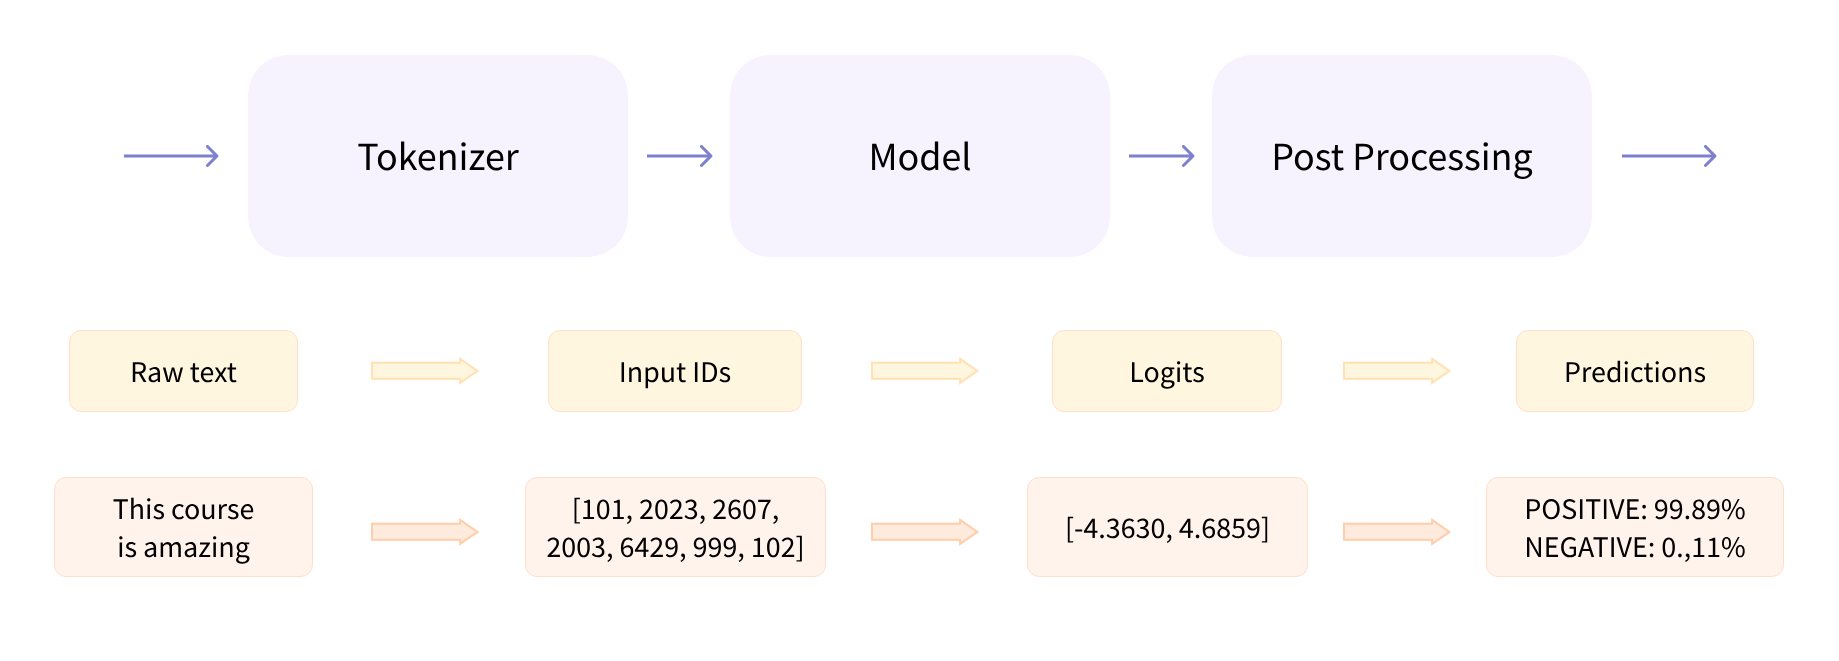

## Preprocessing with a tokenizer
### Like other neural networks, Transformer models can’t process raw text directly, so the first step of our pipeline is to convert the text inputs into numbers that the model can make sense of. To do this we use a tokenizer, which will be responsible for:

  - Splitting the input into words, subwords, or symbols (like punctuation) that are called tokens
  - Mapping each token to an integer
  - Adding additional inputs that may be useful to the model

In [3]:
from transformers import AutoTokenizer

checkpoint = "distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [4]:
raw_inputs = [
    "I am trying to understand how a transformer model works behind the scenes.",
        "I like this so much!",
        "The train ticket was expensive"
]
inputs = tokenizer(raw_inputs, padding=True, truncation=True, return_tensors="pt")
print(inputs)

{'input_ids': tensor([[  101,  1045,  2572,  2667,  2000,  3305,  2129,  1037, 10938,  2121,
          2944,  2573,  2369,  1996,  5019,  1012,   102],
        [  101,  1045,  2066,  2023,  2061,  2172,   999,   102,     0,     0,
             0,     0,     0,     0,     0,     0,     0],
        [  101,  1996,  3345,  7281,  2001,  6450,   102,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])}


#### Attention masks
  - Attention masks are tensors with the exact same shape as the input IDs tensor, filled with 0s and 1s: 1s indicate the corresponding tokens should be attended to, and 0s indicate the corresponding tokens should not be attended to (i.e., they should be ignored by the attention layers of the model).

## Going through the model

In [5]:
from transformers import AutoModel

checkpoint = "distilbert-base-uncased-finetuned-sst-2-english"
model = AutoModel.from_pretrained(checkpoint)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased-finetuned-sst-2-english
Key                   | Status     |  | 
----------------------+------------+--+-
classifier.bias       | UNEXPECTED |  | 
pre_classifier.bias   | UNEXPECTED |  | 
pre_classifier.weight | UNEXPECTED |  | 
classifier.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [6]:
model.config

DistilBertConfig {
  "activation": "gelu",
  "architectures": [
    "DistilBertForSequenceClassification"
  ],
  "attention_dropout": 0.1,
  "bos_token_id": null,
  "dim": 768,
  "dropout": 0.1,
  "dtype": "float32",
  "eos_token_id": null,
  "finetuning_task": "sst-2",
  "hidden_dim": 3072,
  "id2label": {
    "0": "NEGATIVE",
    "1": "POSITIVE"
  },
  "initializer_range": 0.02,
  "label2id": {
    "NEGATIVE": 0,
    "POSITIVE": 1
  },
  "max_position_embeddings": 512,
  "model_type": "distilbert",
  "n_heads": 12,
  "n_layers": 6,
  "output_past": true,
  "pad_token_id": 0,
  "qa_dropout": 0.1,
  "seq_classif_dropout": 0.2,
  "sinusoidal_pos_embds": false,
  "tie_weights_": true,
  "tie_word_embeddings": true,
  "transformers_version": "5.0.0",
  "vocab_size": 30522
}

In [7]:
outputs = model(**inputs)
print(outputs.last_hidden_state.shape)

torch.Size([3, 17, 768])


### About above model output

  - This **"distilbert-base-uncased-finetuned-sst-2-english"** architecture contains only the base Transformer module: given some inputs, it outputs what we’ll call hidden states, also known as features. For each model input, we’ll retrieve a high-dimensional vector representing the **contextual understanding of that input by the Transformer model**.

  - While these **hidden states** can be useful on their own, they’re usually inputs to another part of the model, known as the head.

  - **A high-dimensional vector?**
    - The vector output by the Transformer module is usually large. It generally has three dimensions:

      - Batch size: The number of sequences processed at a time (3 in our example).
      - Sequence length: The length of the numerical representation of the sequence (17 in our example).
      - Hidden size: The vector dimension of each model input.


### Model heads:
  - The model heads take the high-dimensional vector of hidden states as input and project them onto a different dimension. They are usually composed of one or a few linear layers:

  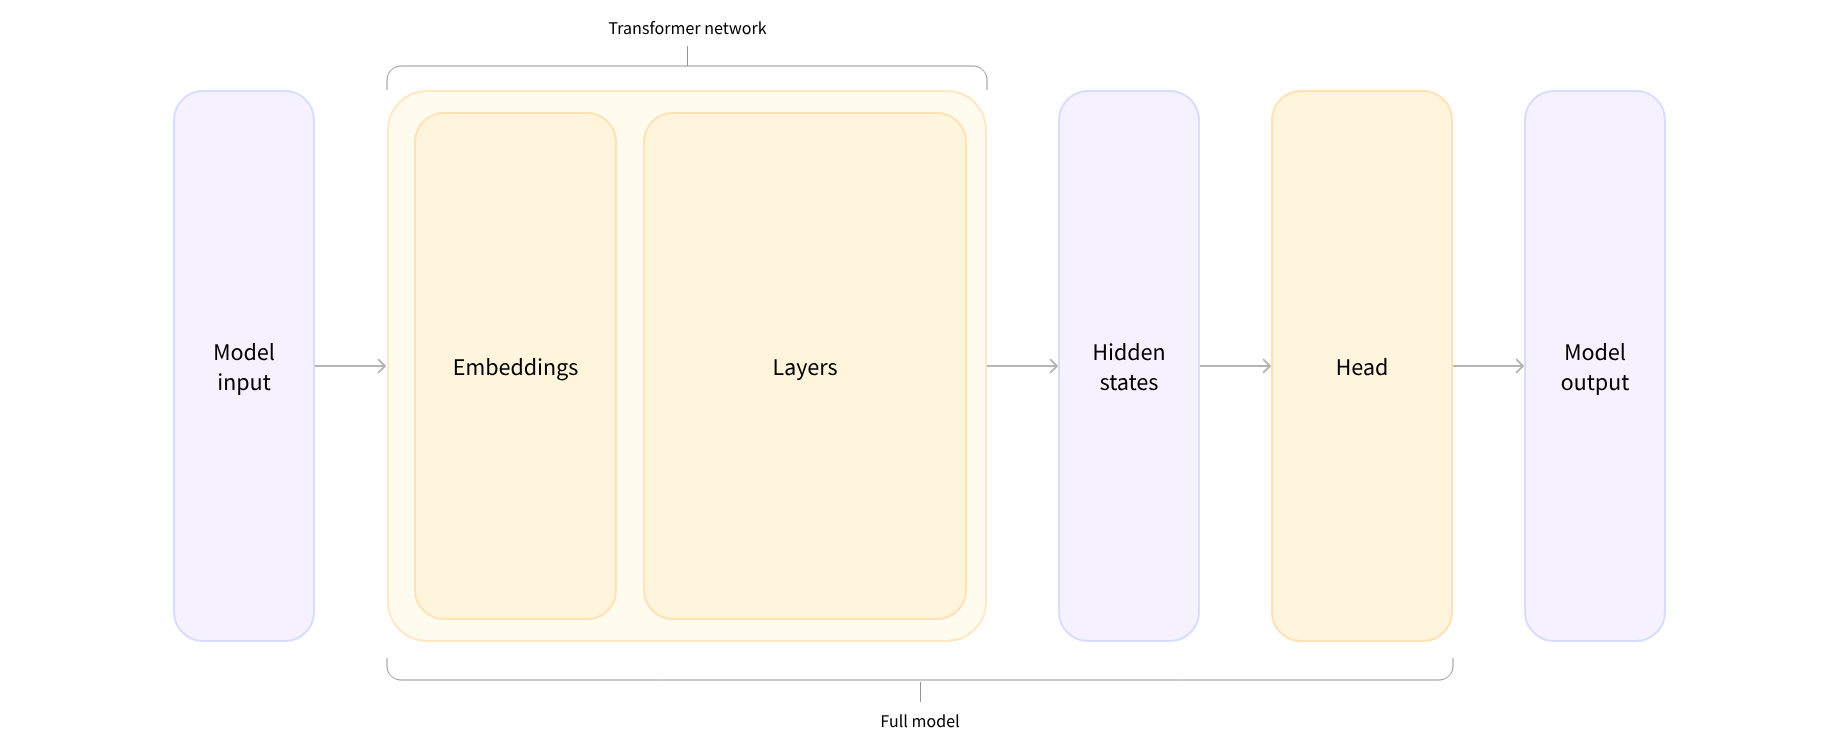

  - The output of the Transformer model is sent directly to the model head to be processed.

  - In this diagram, the model is represented by its embeddings layer and the subsequent layers. The embeddings layer converts each input ID in the tokenized input into a vector that represents the associated token. The subsequent layers manipulate those vectors using the attention mechanism to produce the final representation of the sentences.

  - For our example, we will need a model with a sequence classification head (to be able to classify the sentences as positive or negative). So, we won’t actually use the AutoModel class, but AutoModelForSequenceClassification:

In [8]:
from transformers import AutoModelForSequenceClassification

checkpoint = "distilbert-base-uncased-finetuned-sst-2-english"
model = AutoModelForSequenceClassification.from_pretrained(checkpoint)
outputs = model(**inputs)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [9]:
outputs

SequenceClassifierOutput(loss=None, logits=tensor([[ 2.9813, -2.4612],
        [-4.3435,  4.7064],
        [ 3.6237, -3.0231]], grad_fn=<AddmmBackward0>), hidden_states=None, attentions=None)

In [10]:
print(outputs.logits)

tensor([[ 2.9813, -2.4612],
        [-4.3435,  4.7064],
        [ 3.6237, -3.0231]], grad_fn=<AddmmBackward0>)


  - Now if we look at the shape of our outputs, the dimensionality will be much lower: the model head takes as input the high-dimensional vectors we saw before, and outputs vectors containing two values (one per label):

In [11]:
print(outputs.logits.shape)

torch.Size([3, 2])


## Postprocessing the output

In [12]:
print(outputs.logits)

tensor([[ 2.9813, -2.4612],
        [-4.3435,  4.7064],
        [ 3.6237, -3.0231]], grad_fn=<AddmmBackward0>)


- Our model predicted [ 2.9813, -2.4612] for the first sentence and [-4.3435,  4.7064], third sentence [ 3.6237, -3.0231] for the second one. Those are **not probabilities** but **logits**, the raw, unnormalized scores outputted by the last layer of the model.

- To be converted to probabilities, they need to go through a SoftMax layer (all Transformers models output the logits, as the loss function for training will generally fuse the last activation function, such as SoftMax, with the actual loss function, such as cross entropy):

In [14]:
import torch

predictions = torch.nn.functional.softmax(outputs.logits, dim=-1)
print(predictions)

tensor([[9.9569e-01, 4.3100e-03],
        [1.1738e-04, 9.9988e-01],
        [9.9870e-01, 1.2965e-03]], grad_fn=<SoftmaxBackward0>)


- Now we can see that the **model predicted** [0.996, 0.004] for the first sentence and [0.001, 0.9998], [0.9987, 0.0013] for the second one. These are recognizable probability scores.

In [15]:
model.config.id2label

{0: 'NEGATIVE', 1: 'POSITIVE'}

- Now we can conclude that the model predicted the following:

  - First sentence: NEGATIVE: 0.996, POSITIVE: 0.004
  - Second sentence: NEGATIVE: 0.001, POSITIVE: 0.9998
  - Third sentence: NEGATIVE: 0.9987, POSITIVE: 0.001